# Final Project Report
#### STATS 102 Introduction to Data Science Session 2, 2025 Fall    beijing time

You can zip everything including the data (or box link) and the codes into a zip file and submit through canvas/assignment/final_project


# Nobody Knows the Stock Market Better Than Trump? Construction of "Trump Sentiment-Based Predictor"

- Kuang Sheng (ks729@duke.edu)
- Shangrui Wu (sw710@duke.edu)
- Yutong Tang (yt243@duke.edu)

## 1 Introduction

Financial markets are highly sensitive to political information (Roberts, 1990). Donald J. Trump, the President of the United States, is one of the most influential political figures in the world and is well known for his intensive use of social media, especially Truth Social, where he frequently discloses political views and policy stances. Given his substantial influence on public expectations, we hypothesize that Trump’s social media posts contain emotional and informational signals that may affect investors’ beliefs and thus predict short-term stock market movements.

Motivated by this idea, this study builds a simple text-based prediction model that uses Trump’s daily Truth Social posts to forecast whether the S&P 500 will go up or down on the following trading day. Using natural language processing and supervised machine learning methods, we evaluate three Naive Bayes classifiers (Multinomial, Gaussian, and Bernoulli) as well as Logistic Regression. Our empirical results show that Bernoulli Naive Bayes (BNB) performs best among all models, achieving a prediction accuracy of 72% and a higher F1-score (0.62) in predicting market upturns compared with alternative specifications. In contrast, the predictive power of Logistic Regression is relatively modest in this small-sample, high-dimensional setting.


## 2 Background

This study contributes to several strands of literature in economics and finance. The first strand relates to the Efficient Market Hypothesis (EMH). According to Fama (1970, 1991), in an efficient market, asset prices fully reflect all publicly available information, implying that new public signals, such as Trump’s social media posts, should not generate predictable excess returns. However, this view has been challenged by both theoretical and behavioral approaches. Grossman and Stiglitz (1980) argue that if information were costlessly and fully incorporated into prices, investors would have no incentive to acquire information, which would ultimately cause the market to collapse. From a behavioral perspective, Shiller (1981, 2003) documents excess volatility in stock prices that far exceeds what can be justified by fundamentals, thereby questioning the validity of the EMH. Building on this line of thought, Barberis, Shleifer, and Vishny (1998) develop a theoretical model in which investors systematically overreact or underreact to news due to psychological biases. Motivated by these insights, our study provides suggestive empirical evidence on how investor sentiment shaped by political communication on social media may be reflected in short-term stock market movements.

The second strand of literature focuses on investor sentiment and its predictive role in financial markets. Baker and Wurgler (2007) construct a comprehensive investor sentiment index and show that sentiment exerts stronger predictive power for stocks that are difficult to value and hard to arbitrage, suggesting that behavioral forces are particularly influential when fundamental valuation is ambiguous. Addoum and Kumar (2016) further investigate political sentiment and demonstrate that changes in political power affect firms’ cash flows, investor portfolio allocation, and the returns of politically sensitive industries. While this strand of literature primarily relies on traditional econometric regression methods, our study complements these approaches by introducing machine-learning-based classification models, specifically Naive Bayes and Logistic Regression, to study the predictive content of political sentiment embedded in social media text.

The third strand examines the role of media in predicting financial market behavior. Tetlock (2007) applies a dictionary-based sentiment classification method to Wall Street Journal news content and constructs a negative sentiment index that predicts both market returns and trading volume. Bollen, Mao, and Zeng (2011) utilize OpinionFinder and the Google-Profile of Mood States (GPOMS) to extract emotional states from Twitter data and demonstrate that collective online mood can predict movements in the Dow Jones Industrial Average (DJIA). Chen, De, Hu, and Hwang (2014) focus on Seeking Alpha, an investment-oriented social media platform, and find that both articles and user comments significantly predict stock returns and corporate earnings. Our study contributes to this literature by extending the analysis to Truth Social, a relatively new and politically distinctive platform, thereby providing new evidence on how political sentiment expressed by a major political figure may affect short-run stock market movement.

## 3 Design and Implementation

Our dataset is constructed from two primary sources: the S&P 500 Index obtained from the Wall Street Journal market database (https://www.wsj.com/market-data/quotes/index/SPX/historical-prices#), and the Trump Truth Social Archive collected from GitHub (https://github.com/stiles/trump-truth-social-archive/tree/main/data). From the S&P 500 index data, we construct a binary indicator that classifies daily market movements into “up” or “down” based on next-day closing price changes. From the Truth Social archive, we extract textual features from Donald Trump’s daily posts. The sample period of this study spans from January 22 to October 24, 2025, which corresponds to the early stage of Donald J. Trump’s second presidential term. Due to the termination of updates to the Trump Truth Social Archive after October 26, 2025, posts from November and December are unavailable and therefore excluded from the analysis.

## 3.1 Data Preprocessing: S&P 500 

The data for this project is sourced from the S&P 500 and obtained from The Wall Street Journal (WSJ). The key variable of focus is the closing price of stocks. Utilizing the closing - to - closing logarithmic returns provides several advantages. Logarithmic returns are more suitable for statistical analysis and modeling as they possess desirable mathematical properties, such as being additive over time, which simplifies the analysis of cumulative returns.

The logarithmic return is computed using the formula: 
$$
r_{t+1} = \ln(\text{Close}_{t+1}) - \ln(\text{Close}_t)
$$

Then, a label is assigned to each data point to indicate whether the stock price increased or decreased. If the logarithmic return is greater than 0, the label is set to 1 (indicating an increase); otherwise, it is set to 0 (indicating a decrease). The output of this preprocessing step includes the daily logarithmic returns and the corresponding labels, which will be used for further analysis to predict stock market movements based on Trump's statements.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv('S&P 500 Stock market data.CSV')

# Date formatting
data['Date'] = pd.to_datetime(data['Date'])

# Compute log return
data['log_return'] = np.log(data['Close'].shift(-1)) - np.log(data['Close'])

# Label: 1 = increase, 0 = decrease
data['label'] = np.where(data['log_return'] > 0, 1, 0)

## Visualization 1

The line chart presents the daily closing price trend of the S&P 500 index from January 22 to October 24, 2025. Overall, the market exhibits clear fluctuations with both upward and downward movements, indicating sufficient variation for predictive modeling. The pie chart then summarizes the proportion of up and down days during this period. While the overall distribution is relatively balanced, down days still account for a slightly larger share (57.3%), introducing a degree of class imbalance. As a result, the model’s ability to correctly predict market increases (up movements) becomes a key criterion for distinguishing predictive performance across models.

In [ ]:
# Drop NA for plotting
cp = data.dropna()['Close']
dt = data.dropna()['Date']
ud = data.dropna()['label']

# ------------------------
# Plot 1: Close Price
# ------------------------
plt.figure(figsize=(12, 6))
plt.plot(dt, cp, color='navy', linewidth=2, label='Close Price')

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Close Price of S&P 500 Index (1/22/2025 - 10/24/2025)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Save plot
plt.savefig("sp500_close_price.png", dpi=300)
plt.show()


# ------------------------
# Plot 2: Pie Chart (Up/Down)
# ------------------------
counts = ud.value_counts()
labels = ['Decrease', 'Increase']
sizes = [counts[0], counts[1]]

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#FF6666', '#66CC66'],
    shadow=True
)

plt.title("Up/Down Ratio")
plt.axis('equal')
plt.tight_layout()

# Save pie chart
plt.savefig("sp500_up_down_ratio.png", dpi=300)
plt.show()

## 3.2 Data Preprocessing: Truth Social

Truth Social is an social media platform established by Donald Trump in 2021, positioning itself as a "free speech" alternative to mainstream networks and a central hub for right-wing political discourse. Given the platform's restrictive data access and the ephemeral nature of online content, this study relies on the Truth Social Archive, specifically the open source repository hosted on GitHub. These third-party archives serve a critical function as digital historical records, systematically capturing and preserving posts to ensure data permanence and research accessibility. From this archive, we extracted interaction variables including Replies (replies_count), Reblogs (reblogs_count), and Favourites (favourites_count), which serve as proxies for user engagement and sentiment intensity. As illustrated in the following preprocessing script, the raw archival data was filtered to the study period (Jan 22, 2025 – Oct 24, 2025) and aggregated daily to align with financial market frequencies.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv('truth_archive.csv')
df["date"] = pd.to_datetime(df["created_at"]).dt.date.astype(str)

start_date = "2025-01-22"
end_date = "2025-10-24"
mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_clean = df.loc[mask].drop(columns=['url', 'media', 'created_at']).copy()

pos = df_clean.groupby('date')['id'].count()
pos_mean = pos.mean()

rep = df_clean.groupby('date')['replies_count'].sum()
reb = df_clean.groupby('date')['reblogs_count'].sum()
fav = df_clean.groupby('date')['favourites_count'].sum()

pos.index = pd.to_datetime(pos.index)
rep.index = pd.to_datetime(rep.index)
reb.index = pd.to_datetime(reb.index)
fav.index = pd.to_datetime(fav.index)

## Visualization 2

The first figure shows the daily number of posts published by Trump from January 22 to October 24, 2025. On average, Trump posted 16.97 times per day, indicating a consistently high level of activity on social media. The second figure presents daily engagement, including replies, reblogs, and favorites. Engagement levels remain high throughout the period, suggesting that Trump’s posts attracted widespread attention and sustained public interaction. Together, these figures demonstrate both Trump’s persistent posting behavior and the broad reach of his social media influence.

In [ ]:
# Plot 1: Daily post count
plt.figure(figsize=(12, 6)) 

pos.plot(linewidth=2, label="Posts per day")

# Mean line
plt.axhline(pos_mean, color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = {pos_mean:.2f}')

plt.xlabel("Date")
plt.ylabel("Counts")
plt.title("Daily Number of Posts by Trump (1/22/2025 - 10/24/2025)")
plt.grid(True)

# Rotate x labels and reduce ticks
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.legend()

# Save figure
plt.tight_layout()
plt.savefig("daily_posts.png", dpi=300)
plt.show()

# Plot 2: Replies / Reblogs / Favourites
plt.figure(figsize=(12, 6)) 

rep.plot(label='Replies', color='red', linewidth=2)
reb.plot(label='Reblogs', color='blue', linewidth=2)
fav.plot(label='Favourites', color='green', linewidth=2)

plt.legend(loc='upper left')
plt.xlabel("Date")
plt.ylabel("Counts")
plt.title("Daily Replies / Reblogs / Favourites on Trump’s Posts (1/22/2025 - 10/24/2025)")
plt.grid(True)

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Save figure
plt.tight_layout()
plt.savefig("daily_engagement.png", dpi=300)
plt.show()

## 3.3 Data Preprocessing: Merge
This script merges Trump’s daily Truth Social posts with S&P 500 market data by date. Since the US stock market is not open every day, non-trading days are automatically removed during the merge. Additionally, only the key variables, daily post content, log return, and market movement label are retained for subsequent analysis.

In [ ]:
# truth social
df = pd.read_csv('truth_archive.csv')
df["date"] = pd.to_datetime(df["created_at"]).dt.date.astype(str)

start_date = "2025-01-22"
end_date = "2025-10-24"
mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_clean = df.loc[mask].drop(columns=['url', 'media', 'created_at']).copy()
daily_content = df_clean.groupby('date')['content'].apply(lambda x: ';'.join(x.dropna().astype(str)))

out = daily_content.reset_index()
out.columns = ['Date', 'content']
out.to_csv('daily_content.csv', index=False)

# stock market
data = pd.read_csv('S&P 500 Stock market data.CSV')

data['Date'] = pd.to_datetime(data['Date'])

data['log_return'] = np.log(data['Close'].shift(-1)) - np.log(data['Close'])

data['label'] = np.where(data['log_return'] > 0, 1, 0)
clean_data = data[['Date', 'log_return', 'label']].dropna()

clean_data.to_csv('sp500_log_return_label.csv', index=False)

# merge
daily_content.index = pd.to_datetime(daily_content.index)
clean_data['Date'] = pd.to_datetime(clean_data['Date'])

daily_content_df = daily_content.reset_index()
daily_content_df.columns = ['Date', 'content']

mgdt = pd.merge(daily_content_df, clean_data, on='Date')

mgdt.to_csv('daily_post_stock.csv', index=False)

## 3.4 NLP Cleaning

We performed text preprocessing on Trump’s daily Truth Social posts. It removes URLs, usernames, and special characters, converts all text to lowercase, eliminates common stop words while retaining politically meaningful words (e.g., “we”, “must”), and applies lemmatization to standardize word forms. The cleaned text is then saved as a new dataset for subsequent NLP feature extraction and machine-learning analysis.

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

stop_words = set(stopwords.words('english'))
stop_words -= {"you", "we", "us", "them", "must", "never"}

lemmatizer = WordNetLemmatizer()


def clean_trump_text(text):

    if pd.isna(text) or text == '':
        return ''

    # Remove URLs
    text = re.sub(r'https?://\S+', ' ', text)

    # Lowercase
    text = text.lower()

    # Remove "rt" and usernames
    text = re.sub(r'\brt\b:? ?', ' ', text)   # RT:
    text = re.sub(r'@\w+', ' ', text)         # @username

    # Remove HTML-like patterns
    text = re.sub(r'&[a-z]+;', ' ', text)

    # Keep letters, numbers, whitespace, and "!"
    text = re.sub(r'[^\w\s!]', ' ', text)

    # Tokenize
    words = word_tokenize(text)

    # Remove stopwords and single characters
    words = [word for word in words if word not in stop_words and len(word) > 1]

    # Lemmatize (no POS, but fast and works fine for classification)
    words = [lemmatizer.lemmatize(word) for word in words]

    return ' '.join(words)

df = pd.read_csv('daily_post_stock.csv')

df['cleaned_text'] = df['content'].apply(clean_trump_text)

print(df[['Date', 'cleaned_text']].head())

output_path = "daily_post_stock_cleaned.csv"
df.to_csv(output_path, index=False)
print(f"File exported to: {output_path}")

## Visualization 3

This figure presents a word cloud generated from Trump’s Truth Social posts after NLP cleaning. High-frequency words such as “united,” “state,” “country,” “thank,” “people,” reflecting Trump’s frequent emphasis on nationalism, public support, and political identity. The presence of terms like “republican,” “great,” and “america” suggests that he actively uses this platform to promote his political agenda and mobilize his supporter base.

*This word cloud can not be loaded on the server

In [ ]:
import pandas as pd
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df = pd.read_csv('post_cleantxt_label.csv')
text = " ".join(df['cleaned_text'].dropna())

wc = WordCloud(width=800, height=400).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')

plt.savefig("wordcloud.png", dpi=300)
plt.show()

## 3.5 Model Training

In this section, we conduct model training by first transforming Trump’s daily Truth Social posts into numerical feature vectors using TF-IDF (Term Frequency–Inverse Document Frequency), and then applying three Naive Bayes classifiers, Multinomial, Gaussian, and Bernoulli, for prediction. Model performance is evaluated using multiple metrics, including the confusion matrix, accuracy, precision, recall, F1-score, and ROC–AUC. These evaluation results allow us to identify the most suitable model for predicting next-day stock market movements. In addition, we also explore the use of Logistic Regression as an alternative classification approach.

## TF-IDF
In the context of this study, each document $d$ represents the collection of Donald Trump's Truth Social posts on a given trading day, and each term $t$ represents a specific word appearing in Trump's posts. The TF-IDF weight is constructed as follows:

$$
TF_{t,d} = \frac{n_{t,d}}{\sum_{k} n_{k,d}}
$$

$n_{t,d}$ denotes the number of times word $t$ appears in Trump's posts on day $d$, and the denominator represents the total number of all words posted on that day. Thus, $TF_{t,d}$ captures the relative importance of a word within a single day's political communication.

$$
IDF_t = \log \left( \frac{N}{df_t} \right)
$$

$N$ is the total number of trading days in the sample, and $df_t$ is the number of days in which word $t$ appears at least once. This term reflects how informative or rare a word is across the entire sample period. Words that appear frequently across many days receive lower weights, while more event-specific words receive higher weights.

$$
TF\text{-}IDF_{t,d} = TF_{t,d} \times IDF_t
$$

The resulting TF-IDF score therefore measures the importance of a specific word in Trump's daily posts relative to its overall usage across time. These TF-IDF values serve as the numerical feature vectors used as inputs in the Naive Bayes and Logistic Regression classifiers to predict the next-day movement of the S\&P 500 index.

## Naive Bayes


The Naive Bayes classifier estimates the posterior probability of a market movement label 
$y \in \{0,1\}$ given the TF-IDF feature vector $\mathbf{x}_d$ of Trump’s daily posts using Bayes’ rule:

$$
P(y \mid \mathbf{x}_d) \propto P(y)\prod_{t=1}^{V} P(x_{t,d} \mid y)
$$

where $V$ denotes the vocabulary size and $x_{t,d}$ is the TF-IDF value of term $t$ on day $d$.


For Multinomial Naive Bayes, the conditional probability is defined as:

$$
P(t \mid y) = \frac{N_{t,y} + \alpha}{\sum_k N_{k,y} + \alpha V}
$$

where $N_{t,y}$ denotes the total count of word $t$ in class $y$, $V$ is the vocabulary size, and $\alpha$ is the Laplace smoothing parameter.


For Bernoulli Naive Bayes, each term is treated as a binary indicator of word presence:

$$
P(x_t = 1 \mid y) = \frac{N_{t,y} + \alpha}{N_y + 2\alpha}
$$

where $N_{t,y}$ denotes the number of documents in class $y$ that contain term $t$, and $N_y$ is the total number of documents in class $y$.


For Gaussian Naive Bayes, each feature is assumed to follow a normal distribution:

$$
P(x_t \mid y) = \frac{1}{\sqrt{2\pi\sigma_{t,y}^2}}
\exp\left( -\frac{(x_t - \mu_{t,y})^2}{2\sigma_{t,y}^2} \right)
$$

where $\mu_{t,y}$ and $\sigma_{t,y}^2$ denote the mean and variance of feature $x_t$ within class $y$.


The predicted class is obtained by maximizing the log-posterior probability:

$$
\hat{y} = \arg\max_{y \in \{0,1\}} 
\left[ 
\log P(y) + \sum_{t=1}^{V} \log P(x_{t,d} \mid y) 
\right]
$$


## Random Splitting
The code below first transforms Trump’s daily post text into numerical features using the TF-IDF method, where the maximum number of features is set to 5,000 and 1–2 word combinations are retained. The dataset is then randomly split into a training set (80%) and a testing set (20%) using random sampling. Finally, three Naive Bayes models—Multinomial, Gaussian, and Bernoulli—are trained and evaluated on the test set using accuracy and classification reports.

In [3]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB

df = pd.read_csv("post_cleantxt_label.csv")

X_random = df["cleaned_text"].fillna("")
y_random = df["label"]

tfidf_random = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
X_tfidf_random = tfidf_random.fit_transform(X_random)

X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X_tfidf_random, y_random, test_size=0.2, random_state=42
)

models = {
    "MultinomialNB": MultinomialNB(),
    "GaussianNB": GaussianNB(),
    "BernoulliNB": BernoulliNB()
}

X_train_random_dense = X_train_random.toarray()
X_test_random_dense = X_test_random.toarray()

for name, model in models.items():

    print(f"\n========================")
    print(f" RANDOM SPLIT Model: {name}")
    print("========================")

    if name == "GaussianNB":
        model.fit(X_train_random_dense, y_train_random)
        y_pred_random = model.predict(X_test_random_dense)
    else:
        model.fit(X_train_random, y_train_random)
        y_pred_random = model.predict(X_test_random)

    print("Accuracy:", accuracy_score(y_test_random, y_pred_random))
    print(classification_report(y_test_random, y_pred_random))


 RANDOM SPLIT Model: MultinomialNB
Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

           0       0.71      0.89      0.79        27
           1       0.40      0.17      0.24        12

    accuracy                           0.67        39
   macro avg       0.55      0.53      0.51        39
weighted avg       0.61      0.67      0.62        39


 RANDOM SPLIT Model: GaussianNB
Accuracy: 0.5128205128205128
              precision    recall  f1-score   support

           0       0.68      0.56      0.61        27
           1       0.29      0.42      0.34        12

    accuracy                           0.51        39
   macro avg       0.49      0.49      0.48        39
weighted avg       0.56      0.51      0.53        39


 RANDOM SPLIT Model: BernoulliNB
Accuracy: 0.46153846153846156
              precision    recall  f1-score   support

           0       0.64      0.52      0.57        27
           1       0.24      0.33      0.28   

## Time-based Splitting

However, random splitting may be inappropriate for time-series data and can introduce look-ahead bias (Glasserman & Lin, 2023). Specifically, random sampling may place future observations into the training set, allowing the model to implicitly use information that would not be available at the time of prediction. To avoid this issue, we instead adopt a time-based split, where the last 39 (20%) trading days are used as the test set and all earlier observations are used for training. Except for the sample-splitting procedure, all other modeling steps remain identical to those in the random-split setting.

In [4]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB

df = pd.read_csv("post_cleantxt_label.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

X_text = df["cleaned_text"].fillna("")
y_label = df["label"]

tfidf_ts = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)
X_tfidf_ts = tfidf_ts.fit_transform(X_text)

split_point = int(len(df) * 0.8)

X_train_ts = X_tfidf_ts[:split_point]
X_test_ts  = X_tfidf_ts[split_point:]

y_train_ts = y_label.iloc[:split_point]
y_test_ts  = y_label.iloc[split_point:]

models_ts = {
    "MultinomialNB": MultinomialNB(alpha=1.0),
    "GaussianNB": GaussianNB(),
    "BernoulliNB": BernoulliNB()
}

X_train_ts_dense = X_train_ts.toarray()
X_test_ts_dense  = X_test_ts.toarray()

for name, model in models_ts.items():

    print("\n========================")
    print(f" Time-Series Model: {name}")
    print("========================")

    if name == "GaussianNB":
        model.fit(X_train_ts_dense, y_train_ts)
        y_pred_ts = model.predict(X_test_ts_dense)
    else:
        model.fit(X_train_ts, y_train_ts)
        y_pred_ts = model.predict(X_test_ts)

    print("Accuracy:", accuracy_score(y_test_ts, y_pred_ts))
    print(classification_report(y_test_ts, y_pred_ts))


 Time-Series Model: MultinomialNB
Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

           0       0.66      1.00      0.79        25
           1       1.00      0.07      0.13        14

    accuracy                           0.67        39
   macro avg       0.83      0.54      0.46        39
weighted avg       0.78      0.67      0.56        39


 Time-Series Model: GaussianNB
Accuracy: 0.5641025641025641
              precision    recall  f1-score   support

           0       0.68      0.60      0.64        25
           1       0.41      0.50      0.45        14

    accuracy                           0.56        39
   macro avg       0.55      0.55      0.54        39
weighted avg       0.58      0.56      0.57        39


 Time-Series Model: BernoulliNB
Accuracy: 0.717948717948718
              precision    recall  f1-score   support

           0       0.79      0.76      0.78        25
           1       0.60      0.64      0.62        

## Logistic Regression

Logistic Regression (time-based splitting) is employed as an alternative classification method to predict whether the S\&P 500 index will move up on the next trading day based on the TF-IDF feature vector extracted from Donald Trump’s daily Truth Social posts.

Let $y_d \in \{0,1\}$ denote the market movement on day $d$, where $1$ indicates an upward movement and $0$ indicates a downward movement. Let $\mathbf{x}_d$ represent the TF-IDF feature vector of Trump’s posts on day $d$. Logistic Regression models the conditional probability as:

$$
P(y_d = 1 \mid \mathbf{x}_d) = \frac{1}{1 + e^{-(\beta_0 + \mathbf{x}_d^\top \boldsymbol{\beta})}}
$$

where $\boldsymbol{\beta}$ is the vector of estimated coefficients and $\beta_0$ is the intercept term. The model transforms the linear combination of textual features into a probability using the logistic function.

The predicted class is obtained by:

$$
\hat{y}_d =
\begin{cases}
1, & \text{if } P(y_d = 1 \mid \mathbf{x}_d) \ge 0.5 \\
0, & \text{otherwise}
\end{cases}
$$

In this study, Logistic Regression provides a benchmark linear classifier that links Trump’s textual sentiment signals to the probability of next-day market increases.

In [2]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

df = pd.read_csv("post_cleantxt_label.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

X = df["cleaned_text"].fillna("")
y = df["label"]

split_point = int(len(df) * 0.8)

X_train = X.iloc[:split_point]
X_test  = X.iloc[split_point:]

y_train = y.iloc[:split_point]
y_test  = y.iloc[split_point:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

logreg_model_ts = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ('logreg', LogisticRegression(
        max_iter=2000,
        class_weight='balanced'
    ))
])

logreg_model_ts.fit(X_train, y_train)

y_pred_logreg_ts = logreg_model_ts.predict(X_test)

print("\n=== Logistic Regression (Time-Series Split) ===\n")
print(classification_report(y_test, y_pred_logreg_ts))

Train size: 153
Test size: 39

=== Logistic Regression (Time-Series Split) ===

              precision    recall  f1-score   support

           0       0.64      0.56      0.60        25
           1       0.35      0.43      0.39        14

    accuracy                           0.51        39
   macro avg       0.49      0.49      0.49        39
weighted avg       0.53      0.51      0.52        39



## 3.6 Model Evaluation

After obtaining the exact values of each evaluation metric, we proceed to compare the predictive performance across different models. Two key questions arise. First, among the three Naive Bayes variants (Multinomial, Gaussian, and Bernoulli), which model provides the most reliable classification performance for stock market direction? Second, how does Logistic Regression perform relative to the Naive Bayes family under the same time-series testing framework?

## Accuracy, Precision, Recall, and F1-score
The figure below shows the accuracy, precision, recall, and F1-score for the four models. Notably, we focus on the precision, recall, and F1-score for predicting market increases (“up”). The reasons are twofold. First, there are more “down” days than “up” days in the sample, and this class imbalance causes all models to perform better in predicting market declines, with F1-scores for the “down” class all around or above 0.6. Therefore, a good model should stand out for its ability to predict “up.” Second, successfully predicting market increases is directly linked to potential investment profits.

In terms of accuracy, Bernoulli Naive Bayes achieves the highest value (0.72), indicating the strongest overall predictive performance. Although Multinomial Naive Bayes attains a perfect precision of 100% for predicting “up,” its recall is only 7%, indicating that it almost never predicts market increases and is therefore overly conservative. In contrast, Bernoulli Naive Bayes demonstrates a better balance with 60% precision, 64% recall, and the highest F1-score of 0.62 for the “up” class. This confirms its superior ability to capture upward market signals under class imbalance.

Comparing Bernoulli Naive Bayes with Logistic Regression, the latter only achieves an accuracy of 51%, which is close to random guessing. This suggests that the Naive Bayes framework is more suitable than Logistic Regression for this prediction task under the current data setting.

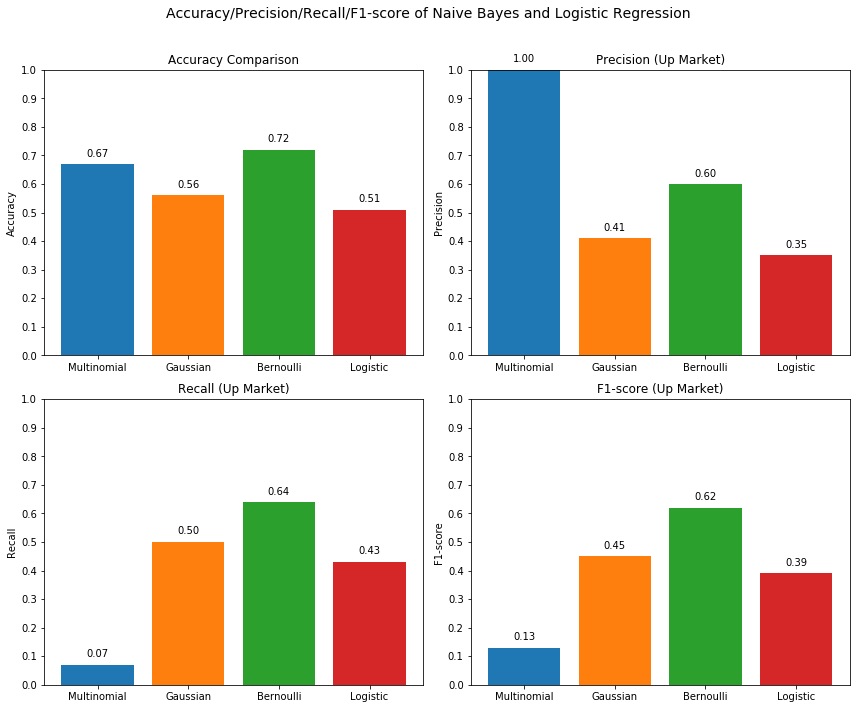

In [15]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Multinomial", "Gaussian", "Bernoulli", "Logistic"]

acc = [0.67, 0.56, 0.72, 0.51]

precision_up = [1.00, 0.41, 0.60, 0.35]
recall_up    = [0.07, 0.50, 0.64, 0.43]
f1_up        = [0.13, 0.45, 0.62, 0.39]

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
yticks = np.arange(0, 1.01, 0.1)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

def draw_bar(ax, values, title, ylabel):
    bars = ax.bar(models, values, color=colors)
    ax.set_ylim(0, 1)
    ax.set_yticks(yticks)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                height + 0.02,
                f"{height:.2f}",
                ha='center', va='bottom', fontsize=10)

draw_bar(axs[0, 0], acc, "Accuracy Comparison", "Accuracy")
draw_bar(axs[0, 1], precision_up, "Precision (Up Market)", "Precision")
draw_bar(axs[1, 0], recall_up, "Recall (Up Market)", "Recall")
draw_bar(axs[1, 1], f1_up, "F1-score (Up Market)", "F1-score")

fig.suptitle("Accuracy/Precision/Recall/F1-score of Naive Bayes and Logistic Regression",
             fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("aprf.png", dpi=300)
plt.show()

## Confusion Matrix
This figure presents the confusion matrices of the three Naive Bayes models and Logistic Regression. Each matrix compares the true market movement (down vs. up) with the model’s predictions. The Multinomial model almost always predicts market declines and rarely identifies upward movements. The Gaussian model shows a more balanced but still imperfect classification. In contrast, the Bernoulli model achieves the best balance between correctly predicting both market decreases and increases. Logistic Regression performs relatively weakly, with more misclassification in both directions. In general, the figure visually confirms that the Bernoulli Naive Bayes model provides the most reliable classification performance among the four models.

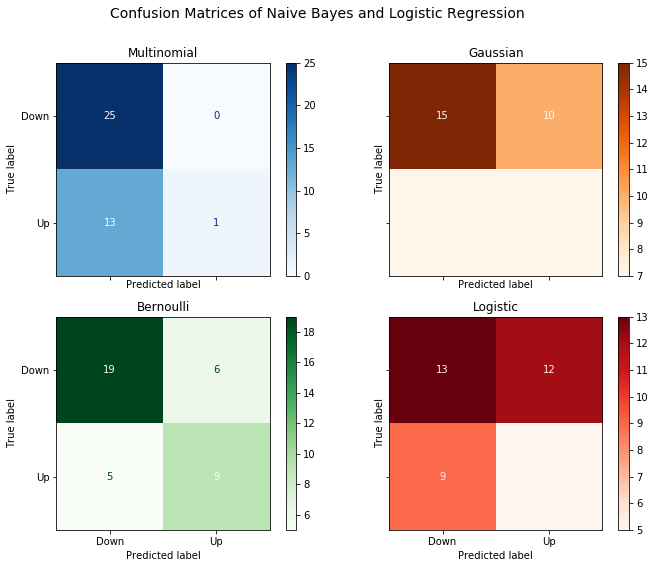

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression

models = {
    "Multinomial": MultinomialNB(alpha=1.0),
    "Gaussian": GaussianNB(),
    "Bernoulli": BernoulliNB(),
    "Logistic": LogisticRegression(max_iter=2000, class_weight="balanced")
}

cmaps = ["Blues", "Oranges", "Greens", "Reds"]

X_train_dense = X_train_ts.toarray()
X_test_dense  = X_test_ts.toarray()

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()  

for ax, (name, model), cmap in zip(axes, models.items(), cmaps):

    if name in ["Gaussian", "Logistic"]:
        model.fit(X_train_dense, y_train_ts)
        y_pred = model.predict(X_test_dense)
    else:
        model.fit(X_train_ts, y_train_ts)
        y_pred = model.predict(X_test_ts)

    cm = confusion_matrix(y_test_ts, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Down", "Up"]
    )

    disp.plot(ax=ax, cmap=cmap, values_format="d")
    ax.set_title(name)

fig.suptitle("Confusion Matrices of Naive Bayes and Logistic Regression",
             fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("confusion matrix.png", dpi=300)
plt.show()


## ROC-AUC

This figure presents the ROC curves and AUC values for the three Naive Bayes models and Logistic Regression. Among all models, Bernoulli Naive Bayes achieves the highest AUC (0.69), showing the strongest overall discriminative ability in separating market “up” and “down” days across different probability thresholds. Logistic Regression reaches an AUC of 0.57, showing only a modest improvement over random guessing. Multinomial (AUC = 0.54) and Gaussian Naive Bayes (AUC = 0.55) perform only slightly better than chance. Overall, the ROC results also confirm that Bernoulli Naive Bayes provides the most stable and reliable probability-based prediction of next-day market direction, consistent with its superior performance in other metrics such as accuracy and F1-score.

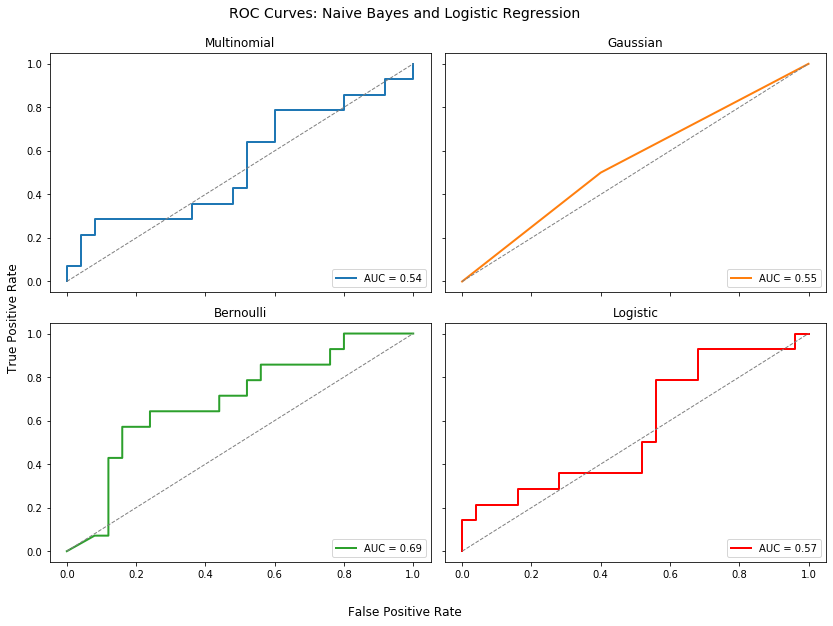

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv("post_cleantxt_label.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

X = df["cleaned_text"].fillna("")
y = df["label"]

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
X_tfidf = tfidf.fit_transform(X)

split_point = int(len(df) * 0.8)

X_train_ts = X_tfidf[:split_point]
X_test_ts  = X_tfidf[split_point:]
y_train_ts = y.iloc[:split_point]
y_test_ts  = y.iloc[split_point:]

X_train_ts_dense = X_train_ts.toarray()
X_test_ts_dense  = X_test_ts.toarray()

models = {
    "Multinomial": MultinomialNB(),
    "Gaussian": GaussianNB(),
    "Bernoulli": BernoulliNB(),
    "Logistic": LogisticRegression(max_iter=2000, class_weight="balanced")
}

colors = {
    "Multinomial": "tab:blue",
    "Gaussian": "tab:orange",
    "Bernoulli": "tab:green",
    "Logistic": "red"
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
axes = axes.flatten()  

for ax, (name, model) in zip(axes, models.items()):

    if name == "Gaussian":
        model.fit(X_train_ts_dense, y_train_ts)
        y_prob = model.predict_proba(X_test_ts_dense)[:, 1]
    else:
        model.fit(X_train_ts, y_train_ts)
        y_prob = model.predict_proba(X_test_ts)[:, 1]

    fpr, tpr, _ = roc_curve(y_test_ts, y_prob)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=colors[name], lw=2,
            label=f"AUC = {roc_auc:.2f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)

    ax.set_title(name)
    ax.legend(loc="lower right")

fig.text(0.5, 0.04, "False Positive Rate", ha="center", fontsize=12)
fig.text(0.04, 0.5, "True Positive Rate", va="center",
         rotation="vertical", fontsize=12)

fig.suptitle("ROC Curves: Naive Bayes and Logistic Regression", fontsize=14)

plt.tight_layout(rect=[0.05, 0.08, 1, 0.95])
plt.savefig("ROC curve.png", dpi=300)
plt.show()

## 4 Results

By comparing the four classification models, all evaluation metrics consistently indicate that the Bernoulli Naive Bayes model is the most suitable for this prediction task, as it achieves the highest overall accuracy, demonstrates a stronger ability to predict market increases, and exhibits better discriminative power between upward and downward movements.

Bernoulli Naive Bayes outperforms the other variants because it models the presence or absence of politically informative keywords as binary signals, which aligns well with the event-driven nature of Trump’s communication and short-term financial market reactions. In other words, whether a key political word appears may matter more than how frequently it appears, making Bernoulli Naive Bayes particularly well-suited for extracting predictive signals from daily political text data.

We further extract the top 10 words that are most predictive of either market increase or decrease. This is based on the log-odds measure implied by the Bernoulli Naive Bayes model:

$$
\text{Log-Odds}(t) = \log P(t \mid y = 1) - \log P(t \mid y = 0)
$$

where $P(t \mid y = 1)$ denotes the probability that word $t$ appears on days when the S\&P 500 index increases, and $P(t \mid y = 0)$ denotes the probability that the word appears on days when the market decreases.

If $\text{Log-Odds}(t) > 0$, the word is more strongly associated with market increases ("up").  
If $\text{Log-Odds}(t) < 0$, the word is more strongly associated with market decreases ("down").

By selecting the 10 largest and 10 smallest values of the log-odds, we obtain the top 10 words with the strongest discriminatory power for predicting market increases and decreases, respectively, and list them in the table below.

In [23]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

X = df["cleaned_text"].fillna("")
y = df["label"]

tfidf = TfidfVectorizer(
    max_features=5000, 
    ngram_range=(1,2), 
    min_df=2
)
X_tfidf = tfidf.fit_transform(X)

split_point = int(len(df) * 0.8)

X_train = X_tfidf[:split_point]
X_test  = X_tfidf[split_point:]

y_train = y.iloc[:split_point]
y_test  = y.iloc[split_point:]

bnb = BernoulliNB()
bnb.fit(X_train, y_train)

feature_names = np.array(tfidf.get_feature_names())

log_prob = bnb.feature_log_prob_
log_odds = log_prob[1] - log_prob[0]

top_up_idx = np.argsort(log_odds)[-10:]
top_up_words = feature_names[top_up_idx]

top_down_idx = np.argsort(log_odds)[:10]
top_down_words = feature_names[top_down_idx]

table = pd.DataFrame({
    "Top 10 UP Words": top_up_words,
    "Top 10 DOWN Words": top_down_words
})

table.to_csv("top10 words.csv", index=False)

table

,Top 10 UP Words,Top 10 DOWN Words
0,state missouri,answer
1,controlled,get vote
2,sadly,great big
3,many thing,wealth
4,missouri,dishonest
5,we agreed,finish
6,backing,stock market
7,order help,prayer
8,mr,patronis
9,support military,we making


## 5 Conclusions

This study investigates whether Donald Trump’s Truth Social posts contain predictive information for next-day movements of the S&P 500 index using text-based machine learning models. By converting daily posts into TF-IDF features and applying three Naive Bayes classifiers and Logistic Regression under a time-series split framework, we find that the Bernoulli Naive Bayes model performs best, achieving the highest accuracy (0.72) and the strongest ability to predict market increases. The results suggest that binary word signals capturing the presence of politically salient keywords are particularly effective in modeling short-term market reactions. Overall, this study provides evidence that political communication on social media can carry economically meaningful sentiment and demonstrates the usefulness of simple NLP-based classification models in financial prediction.

This study has several limitations that point to directions for future research. First, the current sample covers only 192 trading days, which restricts the amount of information available for model training and may limit the generalizability of the results. Future studies can extend the time span to include a much larger volume of political posts and market observations. Second, due to data and funding constraints, this study relies on daily stock market data. However, the superior performance of the Bernoulli Naive Bayes model suggests that the market reacts primarily to whether key political information appears, rather than how frequently it appears. This implies that the market response is likely to be more immediate and short-lived. Future research could therefore adopt minute-level or intraday stock market data to better capture the instantaneous reaction of financial markets to political communication. Third, this study employs relatively traditional textual representations based on TF-IDF. More advanced natural language processing techniques, such as sentiment analysis, enhanced bag-of-words models, or deep-learning-based language models, could be introduced in future work to extract richer semantic information from political texts and further improve predictive performance.

## 6 Individual Contribution

Kuang Sheng: Research design; data acquisition; project coordination; visualization; model training and evaluation; report and poster preparation.

Shangrui Wu: Social media data preprocessing; post text processing and cleaning; report and poster preparation.

Yutong Tang: Stock market data processing; post text processing and cleaning; report preparation and poster proofreading.

## References

Addoum, J. M., & Kumar, A. (2016). Political sentiment and predictable returns. The Review of Financial Studies, 29(12), 3347–3389.

Baker, M., & Wurgler, J. (2006). Investor sentiment and the cross-section of stock returns. The Journal of Finance, 61(4), 1645–1680.

Baker, M., & Wurgler, J. (2007). Investor sentiment in the stock market. Journal of Economic Perspectives, 21(2), 129–151.

Barberis, N., Shleifer, A., & Vishny, R. (1998). A model of investor sentiment. Journal of Financial Economics, 49(3), 307–343.

Bollen, J., Mao, H., & Zeng, X. (2011). Twitter mood predicts the stock market. Journal of Computational Science, 2(1), 1–8.

Chen, H., De, P., Hu, Y. J., & Hwang, B. H. (2014). Wisdom of crowds: The value of stock opinions transmitted through social media. The Review of Financial Studies, 27(5), 1367–1403.

Fama, E. F. (1970). Efficient capital markets: A review of theory and empirical work. The Journal of Finance, 25(2), 383–417.

Fama, E. F. (1991). Efficient capital markets: II. The Journal of Finance, 46(5), 1575–1617.

Glasserman, P., & Lin, S. (2024). Assessing look-ahead bias in stock return predictions generated by GPT sentiment analysis. Journal of Financial Data Science, 6(1), 25–42. 

Grossman, S. J., & Stiglitz, J. E. (1980). On the impossibility of informationally efficient markets. The American Economic Review, 70(3), 393–408.

Roberts, B. E. (1990). Political institutions, policy expectations, and the 1980 election: A financial market perspective. American Journal of Political Science, 34(2), 289–310.

Shiller, R. J. (1981). Do stock prices move too much to be justified by subsequent changes in dividends? The American Economic Review, 71(3), 421–436.

Shiller, R. J. (2003). From efficient markets theory to behavioral finance. Journal of Economic Perspectives, 17(1), 83–104.

Tetlock, P. C. (2007). Giving content to investor sentiment: The role of media in the stock market. The Journal of Finance, 62(3), 1139–1168.

* ChatGPT is employed in this project for polishing code and texts